In [1]:
import networkx as nx, numpy as np, matplotlib.pyplot as plt
import os, importlib

import test_WTM as wtm
import utilsA1 as utils

import gudhi as gd
from collections import Counter, defaultdict
from itertools import combinations



PATH = os.getcwd()
output_file = "Test_GUDHI"
print(PATH)


importlib.reload(wtm)
importlib.reload(utils)

C:\Users\sranasin\Desktop\NetworkModels\Project1\A1


<module 'utilsA1' from 'C:\\Users\\sranasin\\Desktop\\NetworkModels\\Project1\\A1\\utilsA1.py'>

In [ ]:
importlib.reload(wtm)
importlib.reload(utils)

params_temp_list = {'num_nodes': 20, 'num_neighbor_nodes': 1,
                    'total_random_edges': 5, 'distance_threshold': 5, 'weighted': False,
                    'ngeo_placement': 'random.choice', 'n_seeds': 2, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 500, 'skew_power': 3, 'seed_cluster_distance': 5}

G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))


In [ ]:
graph = nx.relabel_nodes(graph, lambda x: int(x))
activation = np.array([int(x) if not np.isnan(x) else np.nan for x in activation_times], dtype = 'object')

In [4]:
print(dict(zip(graph.nodes(), activation.astype(object))))

{0: 3, 1: 2, 2: 1, 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 4, 10: 4, 11: 5, 12: 5, 13: 4, 14: 3, 15: 2, 16: 1, 17: 0, 18: 1, 19: 2}


In [90]:
betti_over_time = {}
simplex_intervals = defaultdict(list)
dim_dict = defaultdict(list)

for t in range(np.nanmax(activation) + 1):
    tree = gd.SimplexTree()
    tree.make_filtration_non_decreasing()
    # tree.initialize_filtration()
    active_nodes = [node for node, time in enumerate(activation) if time <=t ]

    subg = graph.subgraph(active_nodes).copy()
    print(f" Time {t} -----")
    print(f" Active nodes: {subg.nodes()}")
    print(f" Active Edges: {subg.edges()}")

    for node in subg.nodes():
        tree.insert([node], filtration = t )
    for edge in subg.edges():
        edge_filtration = max(activation[edge[0]], activation[edge[1]])
        tree.insert(list(edge), filtration = edge_filtration)

    tree.compute_persistence(min_persistence=0, persistence_dim_max= 2)
    # for birth, death in tree.persistence_pairs():
    #     print(f" Birth : {birth}, Death : {death}")

    # betti_over_time[t] = tree.betti_numbers()
    temp_betti = {}
    for dim in range( 3):
        intervals = tree.persistence_intervals_in_dimension(dim)

        b = sum(1 for birth, death in intervals if birth <= t < death)
        temp_betti[dim] = b
        # temp_intervals = [tuple(arr) for arr in intervals]
        # simplex_intervals[dim].append((t, [tuple(map(object, pair)) for pair in intervals]))
        intervals = intervals.astype(object)
        print(f"Dim : {dim} \n intervals: {intervals} \n ~~~~~~~~~~~~~")
        simplex_intervals[dim].append((t, [tuple(pair) for pair in intervals]))
        # for (birth, death) in intervals:
        #     dim_dict[dim].append((birth, death))
    betti_over_time[t] = temp_betti

    print(f" Betti Numbers: {temp_betti}")



 Time 0 -----
 Active nodes: [17, 3]
 Active Edges: []
Dim : 0 
 intervals: [[0.0 inf]
 [0.0 inf]] 
 ~~~~~~~~~~~~~
Dim : 1 
 intervals: [] 
 ~~~~~~~~~~~~~
Dim : 2 
 intervals: [] 
 ~~~~~~~~~~~~~
 Betti Numbers: {0: 2, 1: 0, 2: 0}
 Time 1 -----
 Active nodes: [2, 3, 4, 16, 17, 18]
 Active Edges: [(2, 3), (3, 4), (16, 17), (17, 18)]
Dim : 0 
 intervals: [[1.0 inf]
 [1.0 inf]] 
 ~~~~~~~~~~~~~
Dim : 1 
 intervals: [] 
 ~~~~~~~~~~~~~
Dim : 2 
 intervals: [] 
 ~~~~~~~~~~~~~
 Betti Numbers: {0: 2, 1: 0, 2: 0}
 Time 2 -----
 Active nodes: [1, 2, 3, 4, 5, 15, 16, 17, 18, 19]
 Active Edges: [(1, 2), (2, 3), (3, 4), (4, 5), (5, 18), (15, 16), (16, 17), (17, 18), (18, 19)]
Dim : 0 
 intervals: [[1.0 2.0]
 [1.0 inf]] 
 ~~~~~~~~~~~~~
Dim : 1 
 intervals: [] 
 ~~~~~~~~~~~~~
Dim : 2 
 intervals: [] 
 ~~~~~~~~~~~~~
 Betti Numbers: {0: 1, 1: 0, 2: 0}
 Time 3 -----
 Active nodes: [0, 1, 2, 3, 4, 5, 6, 14, 15, 16, 17, 18, 19]
 Active Edges: [(0, 1), (0, 19), (1, 2), (1, 14), (2, 3), (3, 4), (4, 5), (5, 6)

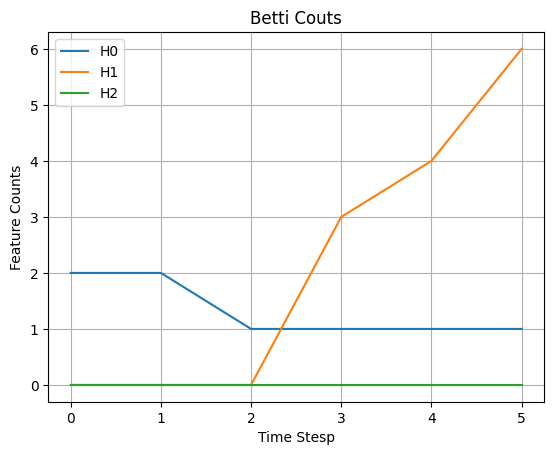

In [87]:

times = sorted(betti_over_time.keys())
dims = sorted(next(iter(betti_over_time.values())).keys())

for dim in dims:
    values = [betti_over_time[t][dim] for t in times]
    plt.plot(times, values, label=f"H{dim}")

plt.xlabel("Time Stesp")
plt.ylabel("Feature Counts")
plt.title("Betti Couts")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
simplex_intervals[0][-1]

(5, [(0.0, inf)])

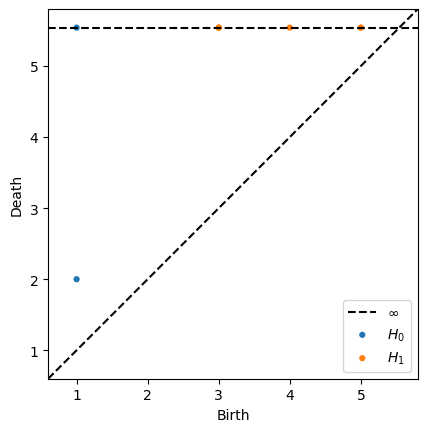

In [88]:
from persim import plot_diagrams

diagrams = []
for dim in range(2):
    latest = simplex_intervals[dim][-1][1]
    diagrams.append(np.array(latest, dtype = np.float64))
plot_diagrams(diagrams, show=True)

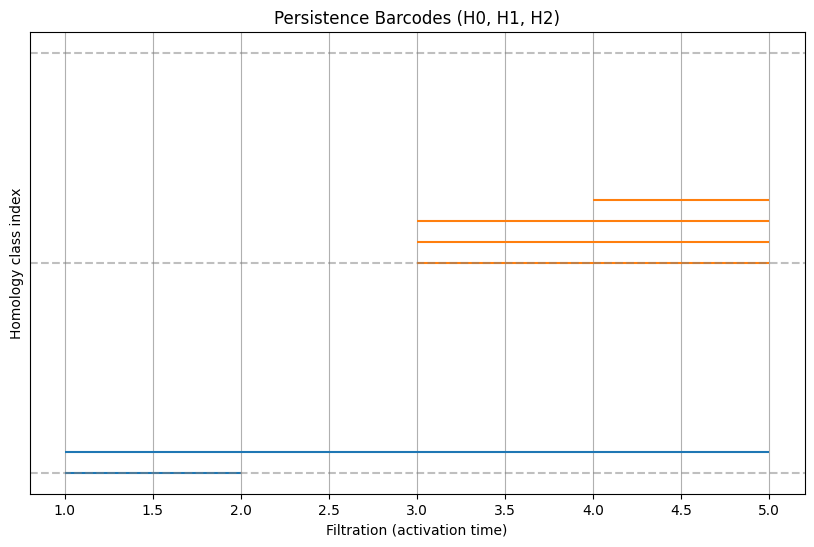

In [101]:
def plot_persistence_barcodes(simplex_interval, activation_times, max_dim=2):
    plt.figure(figsize=(10, 6))
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    for dim in range(max_dim + 1):
        intervals = simplex_intervals[dim][-1][1]
        for i, (birth, death) in enumerate(intervals):
            death_val = death if np.isfinite(death) else max(activation_times)
            plt.hlines(y=dim + i * 0.1, xmin=birth, xmax=death_val, color=colors[dim % len(colors)])
        plt.axhline(dim, linestyle='--', color='gray', alpha=0.5)

    plt.xlabel("Filtration (activation time)")
    plt.ylabel("Homology class index")
    plt.title("Persistence Barcodes (H0, H1, H2)")
    plt.yticks([])
    plt.grid(True)
    plt.show()

def flatten_intervals(simplex_intervals):
    flat = defaultdict(list)
    for dim, timeline in simplex_intervals.items():
        for _, intervals in timeline:
            flat[dim].extend(intervals)
    return flat

flat_intervals = flatten_intervals(simplex_intervals)
plot_persistence_barcodes(simplex_intervals, activation_times, 2)

In [100]:
flat_intervals[0][-1][1]

inf

b### TESTING ###

In [14]:
test = np.array([int(i) if not np.isnan(i) else np.nan for i in np.full([10], np.nan) ])
type(test)

numpy.ndarray

In [29]:
# max_dim = 2
#
# node_times = dict(zip(graph.nodes(), activation_times))
# max_time = int(np.max(activation_times))
#
# betti_over_time = {}
#
# # For Each time step add the subgraph by nodes and vertex to the subtree as a filtration
# # make sure to set non_decreasing()
# for t in range(max_time + 1):
#     active_nodes = [v for v in graph.nodes if node_times[v] <= t]
#     subG = graph.subgraph(active_nodes).copy()
#
#     tree = gudhi.SimplexTree()
#
#     for v in subG.nodes:
#         tree.insert([v], filtration=t)
#
#     cliques = list(nx.find_cliques(subG))
#     # print(cliques)
#     for clique in cliques:
#         for k in range(1, max_dim + 1):
#             for simplex in combinations(clique, k + 1):
#                 tree.insert(simplex, filtration=t)
#
#
#     tree.make_filtration_non_decreasing()
#     tree.compute_persistence()
#     betti_nums = tree.betti_numbers()
#
#     betti_dict = dict()
#     for dim in range(max_dim + 1):
#         if dim < len(betti_nums):
#             betti_dict[dim] = betti_nums[dim]
#         else:
#             betti_dict[dim] = 0
#     betti_over_time[t] = betti_dict

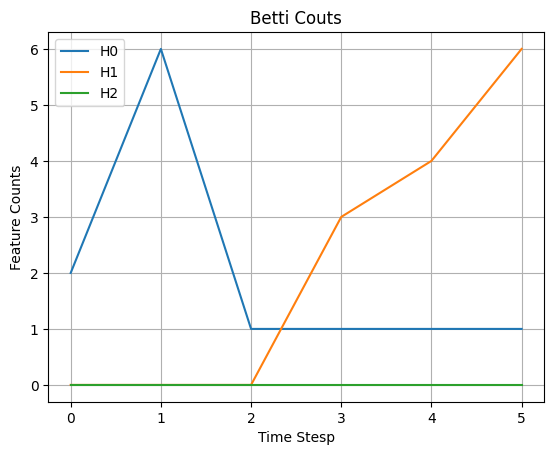

In [52]:


times = sorted(betti_over_time.keys())
dims = sorted(next(iter(betti_over_time.values())).keys())

for dim in dims:
    values = [betti_over_time[t][dim] for t in times]
    plt.plot(times, values, label=f"H{dim}")

plt.xlabel("Time Stesp")
plt.ylabel("Feature Counts")
plt.title("Betti Couts")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
from networkx.algorithms import find_cliques
from collections import defaultdict

def betti_over_time_with_cliques(graph, activation, max_dim=2):
    """
    Track Betti numbers over time for a node-activated graph.

    Parameters:
    - graph: networkx.Graph
    - activation: list of activation times, one per node index
    - max_dim: highest dimension of simplices to track (2 = triangles)

    Returns:
    - dict: { time: { dim: betti_number } }
    """
    max_time = max(activation)
    results = dict()

    for t in range(max_time + 1):
        st = gudhi.SimplexTree()

        # Step 1: Subgraph of active nodes and their edges
        active_nodes = [i for i, val in enumerate(activation) if val <= t]
        subgraph = graph.subgraph(active_nodes)

        # Step 2: Insert vertices (0-simplices)
        for node in subgraph.nodes():
            st.insert([node], filtration=t)

        # Step 3: Insert edges (1-simplices)
        for u, v in subgraph.edges():
            st.insert([u, v], filtration=t)

        # Step 4: Insert cliques up to max_dim (e.g. triangles for dim=2)
        for clique in find_cliques(subgraph):
            if len(clique) <= max_dim + 1:
                st.insert(sorted(clique), filtration=t)

        # Step 5: Finalize + compute persistence
        st.initialize_filtration()
        st.compute_persistence()
        bettis = st.betti_numbers()

        # Store Betti numbers up to max_dim, fill in zeros if needed
        results[t] = {dim: bettis[dim] if dim < len(bettis) else 0 for dim in range(max_dim + 1)}
    print(f"Edges at end: {list(subgraph.edges()
                                )}")
    return results

Edges at end: [(0, 1), (0, 29), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19), (19, 20), (20, 21), (21, 22), (22, 23), (23, 24), (24, 25), (25, 26), (26, 27), (27, 28), (28, 29)]


C:\Users\sranasin\AppData\Local\Temp\ipykernel_23420\1357726246.py:40: DeprecationWarning: Since Gudhi 3.2, calling SimplexTree.initialize_filtration is unnecessary.
  st.initialize_filtration()


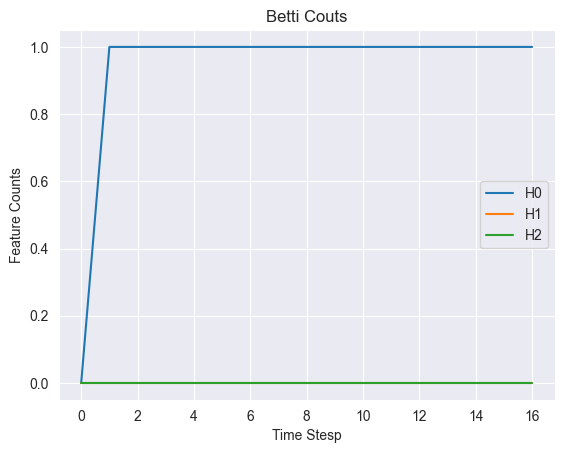

In [23]:
betti_over_time_res = betti_over_time_with_cliques(graph, activation_times.astype(int))

times2 = sorted(betti_over_time_res.keys())
dims2 = sorted(next(iter(betti_over_time_res.values())).keys())

for dim in dims2:
    values = [betti_over_time_res[t][dim] for t in times2]
    plt.plot(times2, values, label=f"H{dim}")

plt.xlabel("Time Stesp")
plt.ylabel("Feature Counts")
plt.title("Betti Couts")
plt.legend()
plt.grid(True)
plt.show()

Edges at end: [(0, 1), (0, 5), (1, 2), (2, 3), (3, 4), (4, 5)]


C:\Users\sranasin\AppData\Local\Temp\ipykernel_23420\1357726246.py:40: DeprecationWarning: Since Gudhi 3.2, calling SimplexTree.initialize_filtration is unnecessary.
  st.initialize_filtration()


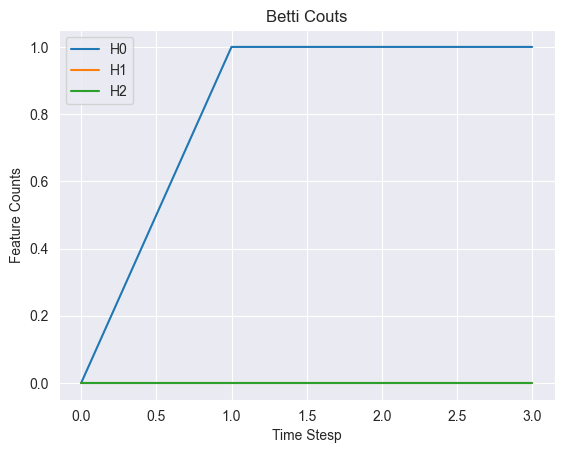

In [32]:
G = nx.cycle_graph(6)  # ring: 0-1-2-3-4-5-0
activation = [3, 2, 1, 0, 1, 2]

betti_over_time_res = betti_over_time_with_cliques(G, activation)
times2 = sorted(betti_over_time_res.keys())
dims2 = sorted(next(iter(betti_over_time_res.values())).keys())

for dim in dims2:
    values = [betti_over_time_res[t][dim] for t in times2]
    plt.plot(times2, values, label=f"H{dim}")

plt.xlabel("Time Stesp")
plt.ylabel("Feature Counts")
plt.title("Betti Couts")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
for t in betti_over_time_res.keys():
    print(f"t={t}: " + ", ".join(f"β{d}={betti_over_time_res[t][d]}" for d in range(3)))

t=0: β0=0, β1=0, β2=0
t=1: β0=1, β1=0, β2=0
t=2: β0=1, β1=0, β2=0
t=3: β0=1, β1=0, β2=0


In [36]:
import networkx as nx
import gudhi

import networkx as nx
import gudhi

def ring_betti_debug_fixed():
    G = nx.cycle_graph(6)  # Ring: 0-1-2-3-4-5-0
    activation = [3, 2, 1, 0, 1, 2]  # Spread from node 3

    for t in range(max(activation) + 1):
        st = gudhi.SimplexTree()
        active_nodes = [i for i, val in enumerate(activation) if val <= t]
        subgraph = G.subgraph(active_nodes)

        print(f"\nTime {t}")
        print(f"  Active nodes: {active_nodes}")
        print(f"  Active edges: {list(subgraph.edges())}")

        # Insert nodes explicitly with filtration = activation time
        for node in active_nodes:
            st.insert([node], filtration=activation[node])  # not just 't'

        # Insert edges where both nodes are active
        for u, v in subgraph.edges():
            st.insert([u, v], filtration=max(activation[u], activation[v]))

        st.initialize_filtration()
        st.compute_persistence()

        betti = st.betti_numbers()
        print(f"  Betti numbers: {betti}")

        print("  Persistence diagram:")
        for dim, pair in st.persistence():
            print(f"    H{dim}: {pair}")


ring_betti_debug_fixed()





Time 0
  Active nodes: [3]
  Active edges: []
  Betti numbers: []
  Persistence diagram:

Time 1
  Active nodes: [2, 3, 4]
  Active edges: [(2, 3), (3, 4)]
  Betti numbers: [1]
  Persistence diagram:
    H0: (0.0, inf)

Time 2
  Active nodes: [1, 2, 3, 4, 5]
  Active edges: [(1, 2), (2, 3), (3, 4), (4, 5)]
  Betti numbers: [1]
  Persistence diagram:
    H0: (0.0, inf)

Time 3
  Active nodes: [0, 1, 2, 3, 4, 5]
  Active edges: [(0, 1), (0, 5), (1, 2), (2, 3), (3, 4), (4, 5)]
  Betti numbers: [1]
  Persistence diagram:
    H0: (0.0, inf)


C:\Users\sranasin\AppData\Local\Temp\ipykernel_23420\590368627.py:28: DeprecationWarning: Since Gudhi 3.2, calling SimplexTree.initialize_filtration is unnecessary.
  st.initialize_filtration()
